In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random 

import time 

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.graph_inference import Graph as Graph_interference
from src.models.graph_training import Graph as Graph_train

# from src.data_loader.transforms_numpy import polar2cartesian, addSpeckleNoise, energyLoss, addBandReflects




- Create instances of graphs
- Load config files

In [ ]:
model_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/model.yaml'
sonar_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'
train_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/training.yaml'

with open(model_config_pth, "r") as f:
    model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
    sonar_config = Box(yaml.safe_load(f))

with open(train_config_pth, "r") as f:
    train_config = Box(yaml.safe_load(f))


PatchGraph_i = Graph_interference(model_config, sonar_config)
PatchGraph_t = Graph_train(model_config, sonar_config, train_config)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

- prepare data 

In [4]:
# test data 

data_pth_sim = f'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/seq_1/fls/352.png'

# read frame 
frame_sim = cv2.imread(data_pth_sim, 0)

frame_sim = frame_sim.astype(np.uint8)
frame_sim = torch.from_numpy(frame_sim) # convert to torch tensor
frame_sim = frame_sim.float().unsqueeze(0).unsqueeze(0).unsqueeze(0)


frames_inm_series = 5
batch_size = 2
t_0 = 1.0
dt = 0.5

frame_sim_b = torch.cat([frame_sim for _ in range(frames_inm_series)], axis = 1)
frame_sim_b = torch.cat([frame_sim_b for _ in range(batch_size)], axis = 0)


time_tensor = torch.tensor([t_0 + i*dt for i in range(frames_inm_series)], device = device, dtype = torch.float)
time_tensor = time_tensor.unsqueeze(0)
time_tensor = torch.cat([time_tensor for _ in range(batch_size)], dim = 0)


print('-'*80)
print(f'Input data format:')
print(f'simulated tensor shape: {frame_sim.shape}, data type: {frame_sim.dtype}')
print(f'simulated tensors batch shape: {frame_sim_b.shape}, data type: {frame_sim_b.dtype}')
print(f'time tensor: {time_tensor.shape}')
print('-'*80)

--------------------------------------------------------------------------------
Input data format:
simulated tensor shape: torch.Size([1, 1, 1, 800, 768]), data type: torch.float32
simulated tensors batch shape: torch.Size([2, 5, 1, 800, 768]), data type: torch.float32
time tensor: torch.Size([2, 5])
--------------------------------------------------------------------------------


### Test 1 - Approximation of next initial position

In [5]:
def plot_test_case(title, p_prev, p_last, p_pred, p_expected=None):
    def to_np(x):
        if x is None: return None
        # Jeśli to już numpy, zwróć. Jeśli tensor, skonwertuj.
        if torch.is_tensor(x): return x.detach().cpu().numpy()
        return x

    # Konwersja wszystkich wejść
    p_prev_np = to_np(p_prev)
    p_last_np = to_np(p_last)
    p_pred_np = to_np(p_pred)
    p_expected_np = to_np(p_expected)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    def draw_frame_full(pose_np, label, length=0.2, is_pred=False):
        pos = pose_np[:3]
        quat = pose_np[3:]
        
        # Rysujemy główny punkt
        size = 150 if is_pred else 100
        ax.scatter(pos[0], pos[1], pos[2], label=label, s=size, edgecolors='k')

        # Obliczamy rotację
        norm = np.linalg.norm(quat)
        if norm > 1e-6:
            r = R.from_quat(quat / norm)
            rot_mat = r.as_matrix()
            
            # Osie: X=czerwony, Y=zielony, Z=niebieski
            colors = ['r', 'g', 'b']
            for i in range(3):
                ax.quiver(pos[0], pos[1], pos[2], 
                          rot_mat[0, i], rot_mat[1, i], rot_mat[2, i], 
                          color=colors[i], length=length, normalize=True, alpha=0.8)
        else:
            print(f"Warning: Zero norm quat for {label}")

    # Rysowanie klatek
    draw_frame_full(p_prev_np, 't_(k-2)')
    draw_frame_full(p_last_np, 't_(k-1)')
    draw_frame_full(p_pred_np, 't_k prediction', length=0.4, is_pred=True)
    
    # Rysowanie punktu oczekiwanego (jeśli podano)
    if p_expected_np is not None:
        pos_ex = p_expected_np[:3]
        ax.scatter(pos_ex[0], pos_ex[1], pos_ex[2], 
                   c='black', marker='x', s=200, label='t_k expected', linewidths=3)
        # Opcjonalnie: dorysowanie osi dla oczekiwanego (półprzezroczyste)
        draw_frame_full(p_expected_np, 'expected', length=0.2)

    # Linia trajektorii
    path = np.array([p_prev_np[:3], p_last_np[:3], p_pred_np[:3]])
    ax.plot(path[:,0], path[:,1], path[:,2], 'k--', alpha=0.4)

    ax.set_title(title)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.legend()
    
    # Automatyczne skalowanie z lekkim marginesem
    all_coords = np.vstack([p_prev_np[:3], p_last_np[:3], p_pred_np[:3]])
    if p_expected_np is not None:
        all_coords = np.vstack([all_coords, p_expected_np[:3]])
        
    mins = all_coords.min(axis=0)
    maxs = all_coords.max(axis=0)
    center = (mins + maxs) / 2
    dist = max(maxs - mins) / 2 + 0.2 # margines
    
    ax.set_xlim(center[0] - dist, center[0] + dist)
    ax.set_ylim(center[1] - dist, center[1] + dist)
    ax.set_zlim(center[2] - dist, center[2] + dist)
    
    plt.show()

In [6]:
# Test data:

# rotation
t_k_2 = 0.5
t_k_1 = 1.0
t_k_0 = 1.5

rot_1_deg = random.randint(0, 90)
rot_2_deg = 2 * rot_1_deg
rot_3_deg = (t_k_0 - t_k_1) / (t_k_1 - t_k_2) * rot_1_deg  + rot_2_deg

# shift 
shift = np.array([random.random(), random.random(), random.random()])

# combine movements
# q_0deg = R.from_euler('z', 0 , degrees=True).as_quat() # init rotation - 0 deg 
q_1 = R.from_euler('z', rot_1_deg , degrees=True).as_quat() # rotation 1 - quaterions
q_2 = R.from_euler('z', rot_2_deg, degrees=True).as_quat() # rotation 2 - 2 * rotation 1 - quaterions
q_3 = R.from_euler('z', rot_3_deg, degrees=True).as_quat() # rotation 3 - 4 * rotation 1 - quaterions

p_t2 = torch.tensor(np.concatenate([[0,0,0], q_1]))  # for time t_k-2
p_t1 = torch.tensor(np.concatenate([shift, q_2]))  # for time t_k-1

# Expected point for time t_k
p_t0  = torch.tensor(np.concatenate([2*shift, q_3]), dtype=torch.float32)

print('-'*50)
print(f'Movement:')
print(f'    shift:\n    x:{shift[0]}\n    y:{shift[1]}\n    z:{shift[2]}')
print(f'    rotation:\n    x: 0\n    y: 0\n    z: {rot_1_deg}')

n = 4



--------------------------------------------------
Movement:
    shift:
    x:0.24127676707359846
    y:0.8751299384077679
    z:0.21515930202213174
    rotation:
    x: 0
    y: 0
    z: 21


Motion model: linear
act n: 4
predicted pose for time t_k-2: tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1822, 0.9833],
       dtype=torch.float64)
predicted pose for time t_k-1: tensor([0.2413, 0.8751, 0.2152, 0.0000, 0.0000, 0.3584, 0.9336],
       dtype=torch.float64)
predicted pose for time t_k: tensor([0.4826, 1.7503, 0.4303, 0.0000, 0.0000, 0.5225, 0.8526])


C:\Users\janis\AppData\Local\Temp\ipykernel_27016\4049833290.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  PatchGraph_i.poses[n-2, :] = torch.tensor(p_t2)
C:\Users\janis\AppData\Local\Temp\ipykernel_27016\4049833290.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  PatchGraph_i.poses[n-1, :] = torch.tensor(p_t1)


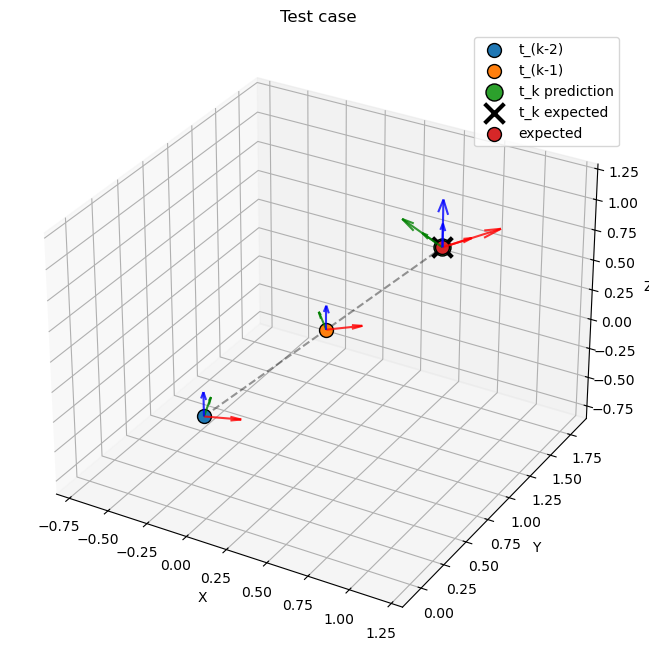

>    Result: PASSED


In [7]:
# =============================================
# Interference graph 
# =============================================


PatchGraph_i.frame_n = n

PatchGraph_i.poses[n-2, :] = torch.tensor(p_t2)
PatchGraph_i.poses[n-1, :] = torch.tensor(p_t1)

PatchGraph_i.time[n-2] = 0.5 #torch.tensor(0.5)
PatchGraph_i.time[n-1] = 1.0 #torch.tensor(1.0)
PatchGraph_i.time[n] = 1.5 #torch.tensor(1.5)

print(f'Motion model: {PatchGraph_i.motion_model}')

PatchGraph_i.approx_movement(device)

p_pred = PatchGraph_i.poses[n, :]

print(f'predicted pose for time t_k-2: {p_t2}')
print(f'predicted pose for time t_k-1: {p_t1}')
print(f'predicted pose for time t_k: {p_pred}')
plot_test_case('Test case', p_t2, p_t1, p_pred, p_expected=p_t0)

if all(list(p_pred.detach().cpu())) == all(list(p_t0.detach().cpu())):
    print('>    Result: PASSED')
else:
    print('>    Result: FAILED')

## Output test


In [22]:


poses, coords_phi = PatchGraph_t.append(frame_sim_b, time_tensor, device)
corr, ctx, source_frame_idx, target_frame_idx, patch_idx = PatchGraph_t.update_step(poses, coords_phi,  device)

print('='*40)
print(f'    corr: {corr.shape}')
print(f'    corr: {ctx.shape}')
print(f'    corr: {source_frame_idx.shape}')
print(f'    corr: {target_frame_idx.shape}')
print(f'    corr: {patch_idx.shape}')

print('='*40)

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 2 but got size 1 for tensor number 1 in the list.

In [16]:
# ----
single_batch = frame_sim_b[0, ...]
single_time = time_tensor[0, ...]

print(single_time)
frames_num = single_time.shape[0]
for i in range(frames_num):
    t_start = time.time()
    frame = single_batch[i, ...].unsqueeze(0).unsqueeze(0)
    ti = single_time[i].unsqueeze(0).unsqueeze(0)
   
    PatchGraph_i.append(frame, ti, device)
    corr, ctx, source_frame_idx, target_frame_idx, patch_idx = PatchGraph_i.update_step(device)
    
    print('='*20, i, '='*20)
    print(f'    edges number: {patch_idx.shape}')
    print(f'    execution time: {time.time()-t_start}')
    print('='*40)

tensor([1.0000, 1.5000, 2.0000, 2.5000, 3.0000])
act n: 10
==================== 0 ====================
    edges number: torch.Size([300])
    execution time: 11.098953008651733
act n: 11
==================== 1 ====================
    edges number: torch.Size([300])
    execution time: 51.776819705963135
act n: 12
==================== 2 ====================
    edges number: torch.Size([300])
    execution time: 33.241400957107544
act n: 13
==================== 3 ====================
    edges number: torch.Size([300])
    execution time: 19.815123796463013
act n: 14
==================== 4 ====================
    edges number: torch.Size([300])
    execution time: 21.67996859550476
